### Perform this filtering, as described from the SCENIC+ methods section

“To ensure high-confidence eRegulons, we required concordance between TF expression and chromatin-based regulon activity. We therefore retained only eRegulons whose region AUC scores strongly correlated with TF expression at the cell-type level, after noise reduction via semi-pseudobulking.”

TF-to-gene relationship, then	region-to-gene relationship
- positive (+)	positive (+)	TF opens chromatin and activates gene expression
- positive (+)	negative (-)	When the TF is expressed the target gene is also expressed but the regions linked to the gene are closed.
- negative (-)	positive (+)	When the TF is expressed the target gene is not expressed. When the target gene is expressed, regions linked to this gene are open. TF could be a chromatin closing repressor.
- negative (-)	negative (-)	When the TF is expressed the target gene is not expressed. When the target gene is expressed, regions linked to this gene are closed.

In [1]:
import pandas as pd 
import numpy as np
import scanpy as sc
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
plots_dir = "regulon_volcano_plots/"

In [3]:
%%time
AUC_df = pd.read_csv("04A_regulon_AUC_df.csv", index_col = 0)

CPU times: user 1.64 s, sys: 359 ms, total: 1.99 s
Wall time: 2.16 s


In [4]:
%%time
RNA_adata = sc.read_h5ad("03_RNA_adata_for_scenicplus.h5ad")

CPU times: user 214 ms, sys: 695 ms, total: 909 ms
Wall time: 1.57 s


In [5]:
umap_colors = {
    "Cardiomyocyte": "#ff7f0e",
    "Endothelial": "#d62728",
    "Fibroblast": "#8c564b",
    "Myeloid": "#aec7e8",
    "Pericyte": "#98df8a",
}

In [6]:
RNA_adata.obs['updated_cell_type'].head()

ENCSR755CIF:ACCACACCATTCCTCG    Cardiomyocyte:female:middle
ENCSR398YBK:TAACCGGTCGTTACAA    Cardiomyocyte:female:middle
ENCSR190TRK:ACATTAGTCATGCTTT    Cardiomyocyte:female:middle
P1582:AGTAACCTCCACCCTA-1-60     Cardiomyocyte:female:middle
H0020_LV:ATACCGAAGAGAGCGG       Cardiomyocyte:female:middle
Name: updated_cell_type, dtype: category
Categories (30, object): ['Cardiomyocyte:female:middle', 'Cardiomyocyte:female:old', 'Cardiomyocyte:female:young', 'Cardiomyocyte:male:middle', ..., 'Pericyte:female:young', 'Pericyte:male:middle', 'Pericyte:male:old', 'Pericyte:male:young']

##### Focus only on the +/+ interactions. If there is direct and extended, keep only the direct

In [7]:
filt_auc_cols = AUC_df.columns[AUC_df.columns.str.contains(r"\+/\+", regex=True)]
filt_AUC_df = AUC_df[filt_auc_cols]

In [8]:
# parse TF name and regulon type
reg_info = (
    pd.DataFrame({"col": filt_auc_cols})
    .assign(
        TF=lambda x: x["col"].str.extract(r"^([^_]+)"),
        type=lambda x: x["col"].str.extract(r"_(direct|extended)_")
    )
)

reg_info["type"] = pd.Categorical(
    reg_info["type"],
    categories=["direct", "extended"],
    ordered=True
)

reg_info = (
    reg_info
    .sort_values("type")
    .drop_duplicates(subset="TF", keep="first")
)

In [9]:
filt_AUC_df = AUC_df[reg_info["col"].values]

In [10]:
filt_AUC_df

,AR_direct_+/+_(49g),SMAD1_direct_+/+_(70g),RUNX1_direct_+/+_(262g),PLAG1_direct_+/+_(84g),PKNOX2_direct_+/+_(24g),PIR_direct_+/+_(33g),PDLIM5_direct_+/+_(51g),PBX3_direct_+/+_(57g),SMAD3_direct_+/+_(104g),NRF1_direct_+/+_(80g),...,NFIA_extended_+/+_(40g),PBX1_extended_+/+_(389g),PRDM5_extended_+/+_(48g),SMAD9_extended_+/+_(100g),SOX7_extended_+/+_(38g),ACAA1_extended_+/+_(11g),ETV1_extended_+/+_(17g),HEY2_extended_+/+_(10g),HEYL_extended_+/+_(92g),TWIST2_extended_+/+_(50g)
Cell,,,,,,,,,,,,,,,,,,,,,
Cardiomyocyte:female:middle_0,0.413860,0.072403,0.018819,0.573541,0.096309,0.325701,0.393860,0.149471,0.054185,0.119913,...,0.142401,0.240717,0.239532,0.032854,0.019394,0.153621,0.126916,0.904839,0.054483,0.009082
Cardiomyocyte:female:middle_1,0.368740,0.073130,0.020434,0.531150,0.083127,0.362696,0.283511,0.186322,0.025816,0.110934,...,0.138275,0.239291,0.230795,0.058027,0.027622,0.031694,0.000000,0.944293,0.046459,0.009826
Cardiomyocyte:female:middle_2,0.352788,0.049114,0.023777,0.504461,0.076613,0.249831,0.342772,0.100888,0.052073,0.107056,...,0.201489,0.211419,0.224592,0.041526,0.000000,0.131514,0.051379,0.812159,0.052271,0.000000
Cardiomyocyte:female:middle_3,0.249861,0.027827,0.026912,0.387023,0.082248,0.216558,0.277599,0.173284,0.040895,0.143533,...,0.071681,0.163440,0.160334,0.042916,0.019002,0.075118,0.000365,0.733499,0.030936,0.000000
Cardiomyocyte:female:middle_4,0.387603,0.081017,0.018113,0.501595,0.128877,0.218212,0.369581,0.174372,0.052777,0.078939,...,0.132816,0.239626,0.200114,0.066600,0.046461,0.178209,0.140709,0.887345,0.047295,0.021861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pericyte:male:young_995,0.105206,0.019940,0.018625,0.096050,0.053763,0.047560,0.155111,0.050956,0.075229,0.049674,...,0.045999,0.104592,0.023134,0.044268,0.027752,0.118430,0.000000,0.196030,0.186360,0.033598
Pericyte:male:young_996,0.089381,0.014782,0.035625,0.100688,0.059657,0.037822,0.160390,0.072396,0.077520,0.054203,...,0.111135,0.121014,0.040814,0.021973,0.000000,0.084931,0.000000,0.271216,0.113483,0.003127
Pericyte:male:young_997,0.102041,0.028536,0.045854,0.082344,0.131876,0.001090,0.150854,0.054721,0.076577,0.048790,...,0.047953,0.092800,0.056633,0.018945,0.014790,0.173697,0.085681,0.167618,0.131150,0.046799


Create function that creates meta-cells for AUC (5 cells per metacell) and for TF expression (100 cells for TF expression), and then perform correlation between AUC (regulon activity) and TF expression across the different cell type categories.

If the correlation is >0.7, then this regulon is considered 'high-quality' and kept for downstream analysis

In [32]:
def correlate_tf_expression_with_regulon_auc(TF, filt_AUC_df,
    RNA_adata, auc_cells_per_meta=5, rna_cells_per_meta=100, random_state=42, plot=True, figsize=(8, 5)):
    
    rng = np.random.default_rng(random_state)

    # find the +/+ regulon for the TF; or raise an immediate error
    regulon_cols = [
        c for c in filt_AUC_df.columns
        if c.startswith(TF + "_") and "+/+" in c]
    if len(regulon_cols) == 0:
        raise ValueError(f"No +/+ regulon found for TF {TF}")
    regulon_col = regulon_cols[0]

    # load in the AUC data
    auc_df = filt_AUC_df[[regulon_col]].copy()
    auc_df["cell_type"] = auc_df.index.str.rsplit("_", n=1).str[0]

    # load in the RNA data, get the TF expression
    rna_obs = RNA_adata.obs.copy()
    rna_obs["cell_type"] = rna_obs["updated_cell_type"]

    rna_obs["TF_expr"] = (
        RNA_adata[:, TF].X.toarray().flatten()
        if hasattr(RNA_adata[:, TF].X, "toarray")
        else RNA_adata[:, TF].X.flatten()
    )

    # build meta-cells and perform correlation per cell type
    meta_records = []

    common_cell_types = sorted( set(auc_df["cell_type"]) & set(rna_obs["cell_type"]) )

    for ct in common_cell_types:
    
        auc_sub = auc_df[auc_df["cell_type"] == ct]
        rna_sub = rna_obs[rna_obs["cell_type"] == ct]
    
        # get AUC meta-cells
        auc_vals = auc_sub[regulon_col].values
        rng.shuffle(auc_vals)
        auc_meta = [
            np.mean(auc_vals[i:i + auc_cells_per_meta])
            for i in range(0, len(auc_vals) - auc_cells_per_meta + 1, auc_cells_per_meta)
        ]
    
        # get the RNA meta-cells
        rna_vals = rna_sub["TF_expr"].values
        rng.shuffle(rna_vals)
        rna_meta = [
            np.mean(rna_vals[i:i + rna_cells_per_meta])
            for i in range(0, len(rna_vals) - rna_cells_per_meta + 1, rna_cells_per_meta)
        ]

        n = min(len(auc_meta), len(rna_meta))
        
        for i in range(n):
            meta_records.append({
                "cell_type": ct,
                "AUC": auc_meta[i],
                "TF_expr": rna_meta[i]
            })
            
    meta_df = pd.DataFrame(meta_records)

    # perform correlation across the TF expression and AUC 
    r, p = pearsonr(meta_df["TF_expr"], meta_df["AUC"])

    # produce plot (if specified)
    if plot: 

        fig, ax = plt.subplots(figsize=figsize)
        
        # for age_status, use shapes
        status_markers = {"fetal": "o", "N": "s", "Y": "^",}

        # use standardized color for cell types
        color_map = {
        "Cardiomyocyte": "#ff7f0e",
        "Endothelial": "#d62728",
        "Fibroblast": "#8c564b",
        "Myeloid": "#aec7e8",
        "Pericyte": "#98df8a",
        }

        # extract the cell type and age_status from the full cell_type plus age_status column
        for ct, sub in meta_df.groupby("cell_type"):
            parts = ct.split(":")
            major_ct = parts[0]
    
            # infer status
            if "fetal" in parts:
                status = "fetal"
            elif "Y" in parts:
                status = "Y"
            else:
                status = "N"
    
            ax.scatter(sub["TF_expr"], sub["AUC"],
                marker=status_markers[status],
                color=color_map.get(major_ct),
                label=f"{major_ct} ({status})",
                s=55, edgecolor="black", linewidth=0.3)

        ax.set_xlabel(f"{TF} expression (meta-cells)")
        ax.set_ylabel(f"{TF} regulon AUC (meta-cells)")
        ax.set_title(f"{TF}: r = {r:.2f}, p = {p:.1e}")

        # deduplicate legend
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(),
            frameon=False, fontsize=8, ncol=2, bbox_to_anchor=(1.05, 1), loc='upper left')
    
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        plt.tight_layout()
        
        res_list = {"TF": TF, "regulon": regulon_col, "r": r, "p": p, "meta_df": meta_df, "fig": fig, "ax": ax}
    else:
        res_list = {"TF": TF, "regulon": regulon_col, "r": r, "p": p, "meta_df": meta_df}
    
    return res_list

### Iterate through all TFs

CPU times: user 418 ms, sys: 158 ms, total: 576 ms
Wall time: 516 ms


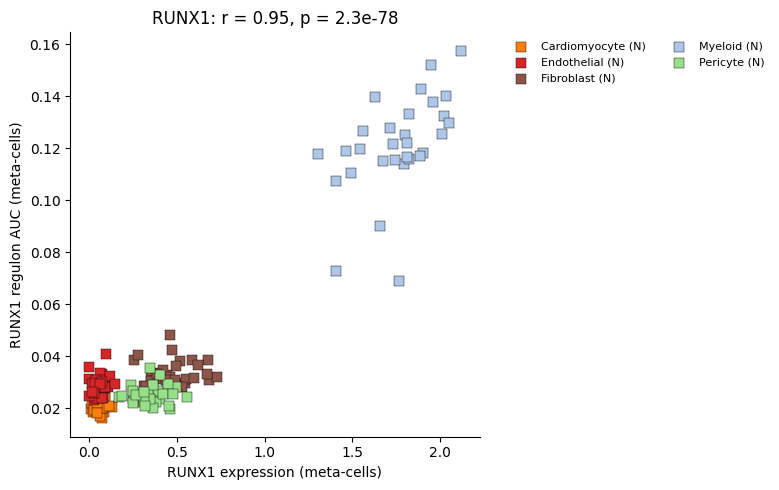

In [33]:
%%time
res = correlate_tf_expression_with_regulon_auc(
    TF="RUNX1",
    filt_AUC_df=filt_AUC_df,
    RNA_adata=RNA_adata, plot=True
)

#### Iterate through all TFs and calculate the correlations

In [34]:
len(filt_AUC_df.columns)

91

In [15]:
%%time

results = []

# use the TF names 
TFs = reg_info['TF']

# iterate through all TFs
for TF in TFs:
    try:
        res = correlate_tf_expression_with_regulon_auc(TF=TF, filt_AUC_df=filt_AUC_df, RNA_adata=RNA_adata, plot=False)
        results.append(res)
        print(f"{TF} (r={res['r']:.2f})")
    except ValueError as e:
        print(f"Error -- skipping {TF}: {e}")

AR (r=0.88)
SMAD1 (r=0.85)
RUNX1 (r=0.95)
PLAG1 (r=0.97)
PKNOX2 (r=0.93)
PIR (r=0.85)
PDLIM5 (r=0.89)
PBX3 (r=0.72)
SMAD3 (r=0.83)
NRF1 (r=0.67)
NR2F2 (r=0.60)
NFYC (r=0.92)
NFIC (r=0.70)
NFIB (r=0.77)
NFE2L2 (r=0.56)
NFE2L1 (r=0.17)
NFATC4 (r=0.83)
NR3C2 (r=0.85)
SMARCC1 (r=0.06)
SOX13 (r=0.75)
SOX18 (r=0.83)
ZNF846 (r=0.48)
ZNF704 (r=0.74)
ZNF565 (r=0.53)
ZNF407 (r=0.76)
ZNF148 (r=0.66)
ZEB1 (r=0.54)
ZBTB20 (r=0.75)
UBE2K (r=0.32)
TFDP2 (r=0.90)
TCF4 (r=0.89)
TCF12 (r=0.34)
TBX5 (r=0.98)
TBX20 (r=0.77)
TBL1XR1 (r=0.55)
SPI1 (r=0.95)
SP6 (r=-0.02)
SOX6 (r=0.87)
MITF (r=0.93)
MEIS2 (r=0.87)
TBX2 (r=0.62)
MEF2C (r=0.62)
EBF3 (r=0.86)
EBF2 (r=0.93)
EBF1 (r=0.91)
E2F8 (r=-0.14)
E2F3 (r=0.71)
E2F1 (r=0.11)
CREM (r=0.79)
CREB5 (r=0.66)
CREB1 (r=0.56)
CHD2 (r=0.04)
BNC2 (r=0.94)
BCL11A (r=0.97)
BACH2 (r=0.89)
BACH1 (r=0.77)
ATF6 (r=0.88)
ATF2 (r=0.19)
MEIS1 (r=0.90)
ELK3 (r=0.94)
ERG (r=0.96)
CHD1 (r=0.19)
ETS2 (r=0.89)
MEF2A (r=0.81)
ETS1 (r=0.88)
MAF (r=0.96)
MAFB (r=0.97)
KLF3 (r=0.80)
KL

In [16]:
# save the correlations 
corr_df = pd.DataFrame([
    {
        "TF": r["TF"],
        "regulon": r["regulon"],
        "r": r["r"],
        "p": r["p"]
    }
    for r in results
])

In [17]:
print(corr_df[corr_df['r'] < 0.7].shape)
print(corr_df[corr_df['r'] > 0.7].shape)

(29, 4)
(62, 4)


In [18]:
high_quality_regulon_df = corr_df[corr_df['r'] > 0.7]
high_quality_regulon_df.to_csv("04B_high_quality_regulon_df.csv")

Visualize some examples

CPU times: user 652 ms, sys: 3.59 s, total: 4.25 s
Wall time: 3.83 s


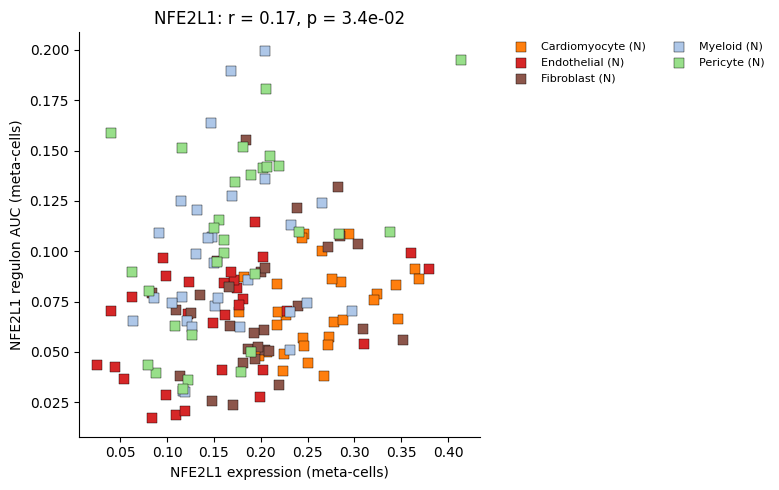

In [21]:
%%time

TF_name = "NFE2L1"

# low correlation example
res = correlate_tf_expression_with_regulon_auc(
    TF=TF_name,
    filt_AUC_df=filt_AUC_df,
    RNA_adata=RNA_adata
)

res['fig'].savefig(plots_dir + TF_name + "_metacell_TF_regulon_corr.pdf")

CPU times: user 833 ms, sys: 657 ms, total: 1.49 s
Wall time: 1.18 s


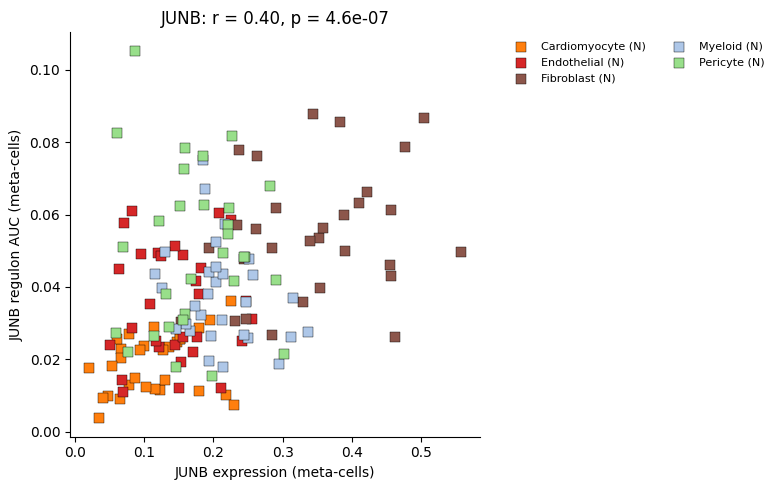

In [22]:
%%time

TF_name = "JUNB"

# low correlation example
res = correlate_tf_expression_with_regulon_auc(
    TF=TF_name,
    filt_AUC_df=filt_AUC_df,
    RNA_adata=RNA_adata
)

res['fig'].savefig(plots_dir + TF_name + "_metacell_TF_regulon_corr.pdf")

CPU times: user 548 ms, sys: 2.37 s, total: 2.92 s
Wall time: 2.67 s


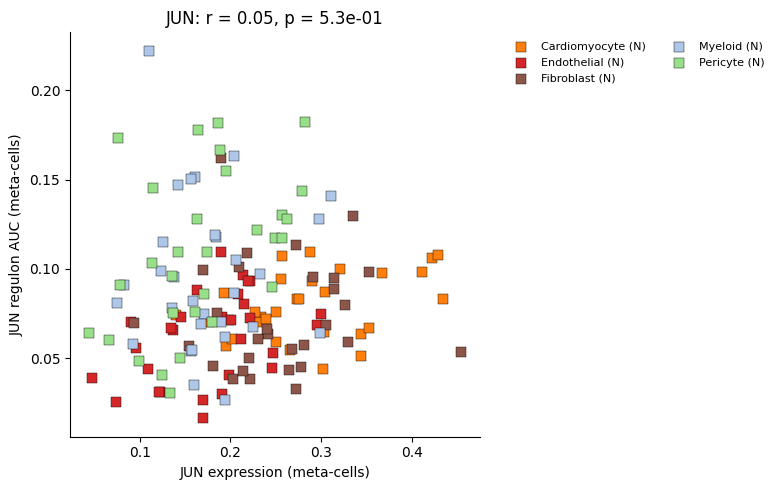

In [23]:
%%time

TF_name = "JUN"

# low correlation example
res = correlate_tf_expression_with_regulon_auc(
    TF=TF_name,
    filt_AUC_df=filt_AUC_df,
    RNA_adata=RNA_adata
)

res['fig'].savefig(plots_dir + TF_name + "_metacell_TF_regulon_corr.pdf")

CPU times: user 593 ms, sys: 1.75 s, total: 2.34 s
Wall time: 2.05 s


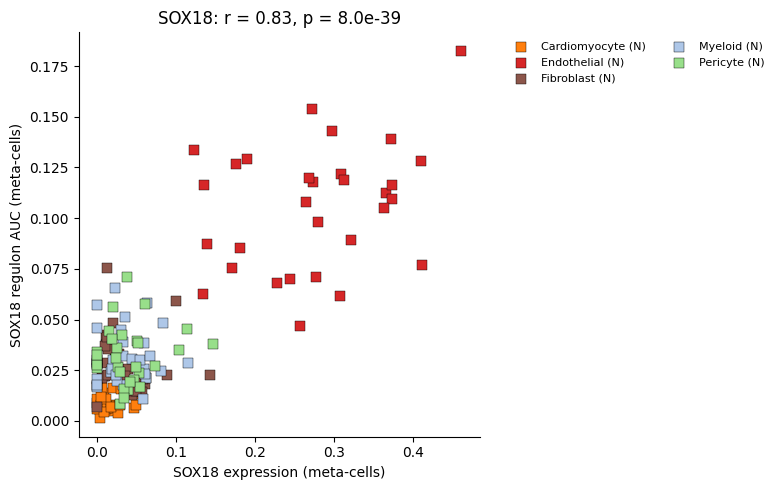

In [24]:
%%time

TF_name = "SOX18"

# low correlation example
res = correlate_tf_expression_with_regulon_auc(
    TF=TF_name,
    filt_AUC_df=filt_AUC_df,
    RNA_adata=RNA_adata
)

res['fig'].savefig(plots_dir + TF_name + "_metacell_TF_regulon_corr.pdf")